## MTH 602 - Homework 1 - Coding Question

William Girard

Due Date: September 21, 2026

In [21]:
import pandas as pd
import numpy as np

### Part 1 - write a function to construct the design (Vandermonde-like) matrix

In [ ]:
df = pd.read_csv('hw1.csv') # assumes csv is in same dir as notebook
df.head(10) # re-labeled columns as t and y

,t,y
0,0.000000,-0.005299
1,0.010101,0.015801
2,0.020202,0.037517
3,0.030303,0.054457
4,0.040404,0.073169
5,0.050505,0.104486
6,0.060606,0.113380
7,0.070707,0.132485
8,0.080808,0.161726
9,0.090909,0.179082


In [9]:
def build_matrix(M, t_values): # where M is degree

    df2 = pd.DataFrame(columns=[list(range(0, M+1))])

    for t in t_values:

        row = []
        for i in range(M+1):
            t_pow = pow(t, i)
            row.append(t_pow)

        df2.loc[len(df2)] = row
        row.clear()

    return df2

t_values = df['t'].values.tolist()

A_3 = build_matrix(3, t_values) # output matrix of shape 100x(M+1), 100x4
A_3

,0,1,2,3
0,1.0,0.000000,0.000000,0.000000
1,1.0,0.010101,0.000102,0.000001
2,1.0,0.020202,0.000408,0.000008
3,1.0,0.030303,0.000918,0.000028
4,1.0,0.040404,0.001632,0.000066
...,...,...,...,...
95,1.0,0.959596,0.920824,0.883619
96,1.0,0.969697,0.940312,0.911818
97,1.0,0.979798,0.960004,0.940610
98,1.0,0.989899,0.979900,0.970002


### Part 2 - compute the least squares solution for a few examples of M = {1, 3, 9}

In [ ]:
from numpy.linalg import lstsq

coeff_3 = lstsq(A_3, df['y'])[0]
coeff_3

array([-0.01198394,  2.15045236, -0.58031445, -0.65380384])

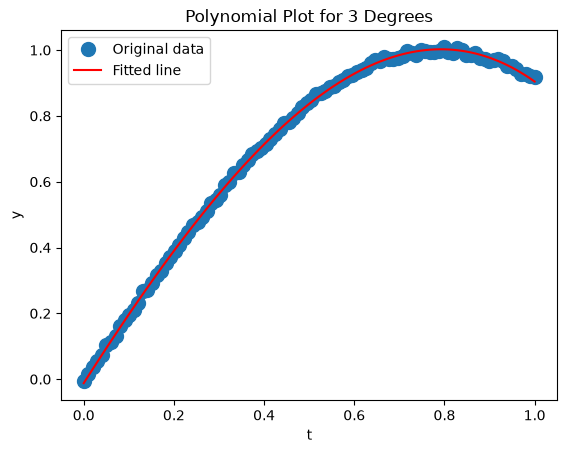

In [100]:
import matplotlib.pyplot as plt
from numpy.polynomial.polynomial import polyval

def plot_polynomial(coeff):
    plt.plot(df['t'], df['y'], 'o', label='Original data', markersize=10)
    plt.plot(df['t'], polyval(df['t'], coeff), 'r', label='Fitted line')  # used to generalize the plotting to any M degree
    plt.title(f'Polynomial Plot for {len(coeff)-1} Degrees')
    plt.xlabel('t')
    plt.ylabel('y')
    plt.legend()
    plt.show()

plot_polynomial(coeff_3)

Looks like a pretty well-fit line, now to do the same for the other examples, that being 1 and 9 degrees of freedom.

In [15]:
A_1 = build_matrix(1, t_values) # output matrix of shape 100x(M+1), 100x4
coeff_1 = np.linalg.lstsq(A_1, df['y'])[0]
coeff_1

array([0.21385187, 0.97974657])

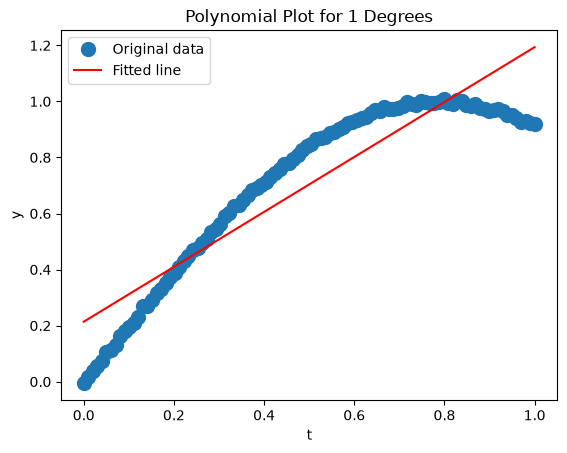

In [101]:
def plot_polynomial(coeff):
    plt.plot(df['t'], df['y'], 'o', label='Original data', markersize=10)
    plt.plot(df['t'], polyval(df['t'], coeff), 'r', label='Fitted line')
    plt.title(f'Polynomial Plot for {len(coeff)-1} Degrees')
    plt.xlabel('t')
    plt.ylabel('y')
    plt.legend()
    plt.show()

plot_polynomial(coeff_1)

Looks logical. Since 1 degree of freedom would just be a y=mx+b line, it can't do a very good job fitting the higher degree data.

In [17]:
A_9 = build_matrix(9, t_values) # output matrix of shape 100x(M+1), 100x4
coeff_9 = np.linalg.lstsq(A_9, df['y'])[0]
coeff_9

array([-5.47999322e-03,  2.11139307e+00, -2.65896280e+00,  2.60203093e+01,
       -1.42936639e+02,  4.21079806e+02, -7.27629306e+02,  7.32511408e+02,
       -3.97314797e+02,  8.97384994e+01])

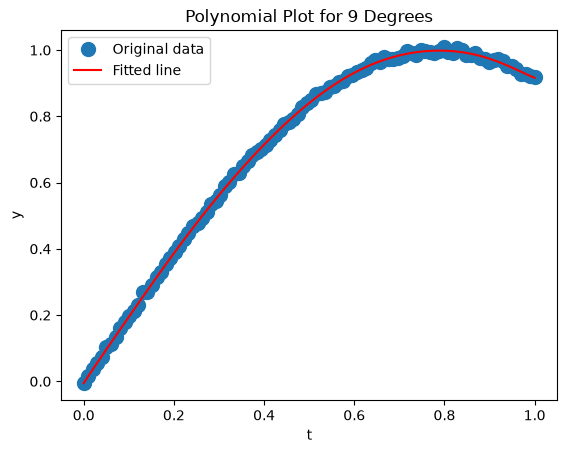

In [102]:
def plot_polynomial(coeff):
    plt.plot(df['t'], df['y'], 'o', label='Original data', markersize=10)
    plt.plot(df['t'], polyval(df['t'], coeff), 'r', label='Fitted line')
    plt.title(f'Polynomial Plot for {len(coeff)-1} Degrees')
    plt.xlabel('t')
    plt.ylabel('y')
    plt.legend()
    plt.show()

plot_polynomial(coeff_9)

Looks pretty good! Very similar to the 3 degrees of freedom plot.

### Part 3 - Training vs. Testing Error

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

t_train, t_test, y_train, y_test = train_test_split(df['t'], df['y'], test_size=0.2, random_state=42) # test = 20%, train = 80%

for M in [1, 3, 9]:
    A_train = build_matrix(M, t_train)
    A_test = build_matrix(M, t_test)
    coeff = lstsq(A_train, y_train)[0]

    y_train_pred = A_train @ coeff # perform matrix mult
    train_mse = mean_squared_error(y_train, y_train_pred)

    y_test_pred = A_test @ coeff 
    test_mse = mean_squared_error(y_test, y_test_pred)

    print(f'Degree: {M} - Train MSE: {train_mse} - Test MSE: {test_mse}')


Degree: 1 - Train MSE: 0.01515603535546547 - Test MSE: 0.01117420746168989
Degree: 3 - Train MSE: 3.557350810119884e-05 - Test MSE: 3.824914368717805e-05
Degree: 9 - Train MSE: 2.50592905520812e-05 - Test MSE: 2.952583740302589e-05


In all degrees, the testing MSE is slightly higher, this is normal. Also, it wasn't visible from the plot, but 9 degrees of freedom has less error than 3 degrees of freedom.

### Part 4 - Condition Number and Stability

In [103]:
from numpy.linalg import cond 
from numpy.random import choice

cond_dict = {}
rng = np.random.default_rng(seed=42) # set random seed for reproducibility 

for M in [1, 3, 9]:
    for N in [10, 40, 100]:
        
        idx = rng.choice(len(df), size=N, replace=False) # replace = False to prevent duplicates
        t_sample, y_sample = df['t'].values[idx], df['y'].values[idx]

        A = build_matrix(M, t_sample)
        cond_number = cond(A)

        cond_dict.update({(M, N): cond_number})

cond_dict
    

{(1, 10): np.float64(4.13053601478359),
 (1, 40): np.float64(4.830324597500499),
 (1, 100): np.float64(4.348660714551691),
 (3, 10): np.float64(136.5571979064974),
 (3, 40): np.float64(135.06290634433205),
 (3, 100): np.float64(121.09290651884733),
 (9, 10): np.float64(223309204756.3413),
 (9, 40): np.float64(6926470.387313724),
 (9, 100): np.float64(3720104.410893332)}

In [104]:
# create three conditional value lists for each N

N_10 = []
N_40 = []
N_100 = []

for key, value in cond_dict.items():
    if 10 in key:
        N_10.append(cond_dict[key])
    elif 40 in key:
        N_40.append(cond_dict[key])
    else:
        N_100.append(cond_dict[key])

print(N_10) # print conditional numbers for N=10, as an example
        

[np.float64(4.13053601478359), np.float64(136.5571979064974), np.float64(223309204756.3413)]


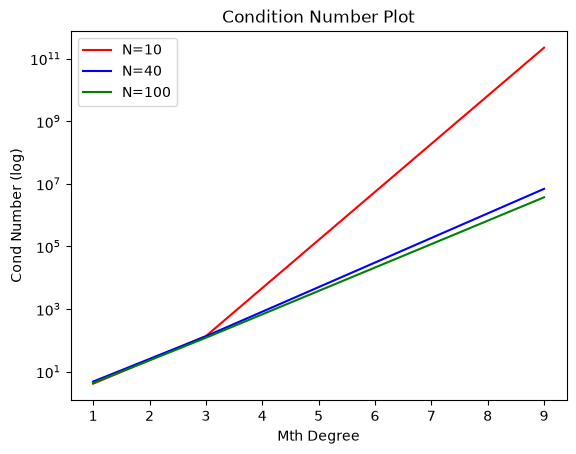

In [105]:
M_list = [1, 3, 9]

fig, ax = plt.subplots()

ax.plot(M_list, N_10, 'r', label='N=10')
ax.plot(M_list, N_40, 'b', label='N=40')
ax.plot(M_list, N_100, 'g', label='N=100')

ax.set_yscale('log') # log scale because some conditional numbers are very very high
ax.set_xlabel('Mth Degree')
ax.set_ylabel('Cond Number (log)')

plt.title(f'Condition Number Plot')
plt.legend()
plt.show()

A large condition number implies an unstable solution. In other words, small changes in the outputs (y-axis) turn into large values/variations in omega (the optimal coefficients). This is shown the most with N=10 and M=9, aka, interpolation. The coefficients are very high and the curve fits the points perfectly, but it is a very unstable solution as a result.

From purely conditioning viewpoint, the lowest condition number is obtained when N=10 and M=1. This makes sense because we are dealing with a linear function, therefore, there won't be very much variation. However, we know that a linear function will not fit this data very well. Therefore, a reasonable value of N would be 100, while a reasonable value of M would be 3. 

### Part 5 - Model Selection and Overfitting

In [ ]:
# pass in N, where N is the sampling size

def model_metrics(N): 
    M_dict = {}

    rng = np.random.default_rng(seed=42) # set random seed for reproducibility
    idx = rng.choice(len(df), size=N, replace=False)
    t_sample, y_sample = df['t'].values[idx], df['y'].values[idx]
    
    t_train, t_test, y_train, y_test = train_test_split(t_sample, y_sample, test_size=0.2, random_state=42)

    for M in range(0, 10):
        
        A_train = build_matrix(M, t_train)
        A_test = build_matrix(M, t_test)
        coeff = lstsq(A_train, y_train)[0]

        y_train_pred = A_train @ coeff
        train_mse = mean_squared_error(y_train, y_train_pred)

        y_test_pred = A_test @ coeff 
        test_mse = mean_squared_error(y_test, y_test_pred)

        A = build_matrix(M, t_sample)
        cond_number = cond(A)

        M_dict.update({M: [train_mse, test_mse, cond_number]}) # associate each degree with the three metrics

    train_mse_list = []
    test_mse_list = []
    cond_number_list = []

    for key, value in M_dict.items():
        print(f'{key} Degree - Metrics (train mse, test mse, cond): {value}')

        # extract values as lists for future plotting
        train_mse_list.append(value[0])
        test_mse_list.append(value[1])
        cond_number_list.append(value[2])

    return M_dict, train_mse_list, test_mse_list, cond_number_list

M_dict, train_mse_list, test_mse_list, cond_number_list = model_metrics(N=100)

0 Degree - Metrics (train mse, test mse, cond): [0.10771785985628113, 0.0522095021206038, np.float64(1.0)]
1 Degree - Metrics (train mse, test mse, cond): [0.013901903177869393, 0.016921562012639186, np.float64(4.348660714551691)]
2 Degree - Metrics (train mse, test mse, cond): [0.00019867388701256183, 0.00020313564437171382, np.float64(22.46197627095659)]
3 Degree - Metrics (train mse, test mse, cond): [3.621339598174719e-05, 3.490072448864398e-05, np.float64(121.09290651884712)]
4 Degree - Metrics (train mse, test mse, cond): [2.3587917666898318e-05, 3.814555191601915e-05, np.float64(665.2036592725409)]
5 Degree - Metrics (train mse, test mse, cond): [2.355657581692815e-05, 3.742339241696265e-05, np.float64(3694.0335110156825)]
6 Degree - Metrics (train mse, test mse, cond): [2.3318669889274937e-05, 4.031369138402526e-05, np.float64(20663.36338486282)]
7 Degree - Metrics (train mse, test mse, cond): [2.330857214770956e-05, 4.030372089105782e-05, np.float64(116207.01902298423)]
8 Degr

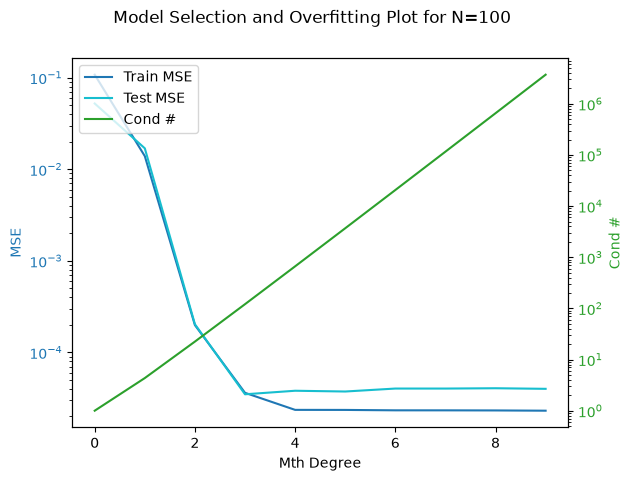

In [ ]:
# cite: https://www.geeksforgeeks.org/python/matplotlib-axes-axes-twinx-in-python/

def model_selection_plots(train_mse_list, test_mse_list, cond_number_list, N):
    M = list(range(0, 10))

    fig, (ax1) = plt.subplots() 

    color = 'tab:blue'
    ax1.set_xlabel('Mth Degree')
    ax1.set_ylabel('MSE', color=color)
    ax1.set_yscale('log') # use log scale for MSE as well 
    ax1.plot(M, train_mse_list, label='Train MSE', color=color)
    ax1.plot(M, test_mse_list, label='Test MSE', color='tab:cyan') # different blue hue to differentiate the curves
    ax1.tick_params(axis ='y', labelcolor = color) 

    ax2 = ax1.twinx()

    color = 'tab:green'
    ax2.set_ylabel('Cond #', color=color)
    ax2.set_yscale('log')
    ax2.plot(M, cond_number_list, label='Cond #', color=color)
    ax2.tick_params(axis ='y', labelcolor = color) 

    fig.suptitle(f'Model Selection and Overfitting Plot for N={N}')

    # groups all labels from both axes together into a single legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    plt.show()

model_selection_plots(train_mse_list, test_mse_list, cond_number_list, 100)

0 Degree - Metrics (train mse, test mse, cond): [0.08234645894711652, 0.07728779021109862, np.float64(1.0)]
1 Degree - Metrics (train mse, test mse, cond): [0.010821252972466805, 0.014216530321066855, np.float64(4.840550711154211)]
2 Degree - Metrics (train mse, test mse, cond): [0.00016734856268041116, 0.00012212623852869649, np.float64(25.478326115381925)]
3 Degree - Metrics (train mse, test mse, cond): [3.860744834667945e-05, 3.305939523286965e-05, np.float64(147.8596609453178)]
4 Degree - Metrics (train mse, test mse, cond): [3.060361292708408e-05, 1.7772086786419026e-05, np.float64(972.6073789439041)]
5 Degree - Metrics (train mse, test mse, cond): [2.4399267458262915e-05, 4.0720702303583544e-05, np.float64(5822.852839531546)]
6 Degree - Metrics (train mse, test mse, cond): [2.436704187156955e-05, 4.103437691174229e-05, np.float64(35631.29683579945)]
7 Degree - Metrics (train mse, test mse, cond): [2.4260566994561194e-05, 4.1681349153240374e-05, np.float64(231450.77305330563)]
8 D

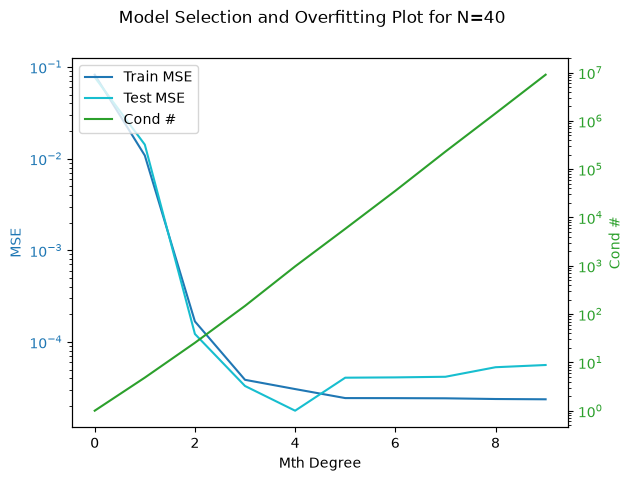

In [93]:
M_dict, train_mse_list, test_mse_list, cond_number_list = model_metrics(N=40)
model_selection_plots(train_mse_list, test_mse_list, cond_number_list, 40)

0 Degree - Metrics (train mse, test mse, cond): [0.11148555581951819, 0.09982094766424687, np.float64(1.0)]
1 Degree - Metrics (train mse, test mse, cond): [0.01755154682625116, 0.009199607395980377, np.float64(4.13053601478359)]
2 Degree - Metrics (train mse, test mse, cond): [0.00013395616667268375, 0.0004009040695971116, np.float64(23.645075236703324)]
3 Degree - Metrics (train mse, test mse, cond): [1.564761059390283e-05, 1.3580608253830836e-05, np.float64(169.90892244669854)]
4 Degree - Metrics (train mse, test mse, cond): [1.2832169600770855e-05, 4.8395684136020424e-05, np.float64(1172.9414287580812)]
5 Degree - Metrics (train mse, test mse, cond): [5.731577578315421e-06, 0.00047463385057511573, np.float64(7270.224549852953)]
6 Degree - Metrics (train mse, test mse, cond): [4.1219607171578523e-07, 0.00035668412318046124, np.float64(79585.22432464562)]
7 Degree - Metrics (train mse, test mse, cond): [1.2621255445416177e-27, 0.0007349284258840209, np.float64(585926.647174012)]
8 De

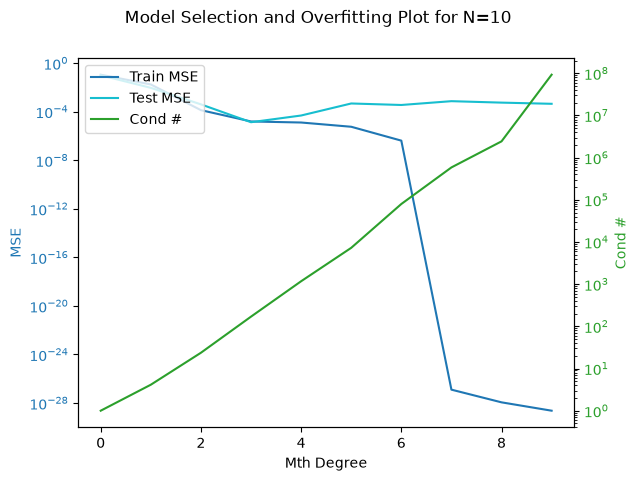

In [94]:
M_dict, train_mse_list, test_mse_list, cond_number_list = model_metrics(N=10)
model_selection_plots(train_mse_list, test_mse_list, cond_number_list, 10)

Now that all training subsample sizes have been investigated (N= 10, 40, 100), it is time for model selection.

To start with the obvious: 
- When N=10, the model becomes severely overfit for degrees 7, 8, and 9, with degree=9 being direct interpolation.
- For all plots, a higher degree = a higher condition number. This makes sense, giving the model more degrees of freedom allows for small changes in the outputs to have large outcomes. 
- The lowest condition numbers are when N=100, with the highest numbers being when N=10. A reasonable conclusion is that more data allows the model to become better conditioned and more confident in its chosen coefficients.

A strong solution should have good training + testing MSE (without overfitting) and a reasonably low condition number. 

To start, I will choose N=100 to minimize the condition number. I value strong success on the testing dataset, since it is new unseen samples to the model. If a model performs strongly on unseen samples, it is a good sign it can generalize well.

With that in mind, I argue for degree M = 3 and N = 100. These are the metrics:
- 3 Degree - Metrics (train mse, test mse, cond): [3.621339598174719e-05, 3.490072448864398e-05, np.float64(121.09290651884712)]
- This degree has the lowest testing MSE for all degrees when N = 100 and maintains a low condition number of 121. 
- Therefore, I think it is a strong choice.

In [107]:
# now all thats left to do is to store my chosen coefficients in a txt file

t_train, t_test, y_train, y_test = train_test_split(df['t'], df['y'], test_size=0.2, random_state=42) # use whole df since N = 100
A_train = build_matrix(3, t_train) # M=3
coeff = lstsq(A_train, y_train)[0]
coeff


array([-0.0113339 ,  2.14092232, -0.55290349, -0.67212336])

In [108]:
np.savetxt('bonus.txt', coeff)

In [ ]:
# verify it can be loaded
coeff = np.loadtxt('bonus.txt')
coeff